# 03 · How the shade score works

This notebook walks through the shadow-polygon algorithm on **one street** of one Indian city, so the mechanics are inspectable end-to-end.

Pipeline in three panels:
1. Building footprints and the street segment we care about
2. Each building's 2-D ground shadow at the chosen sun angle
3. Sampled points along the street coloured by shaded / sunlit

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import LineString

from src.config import CITIES
from src.data_loader import load_area
from src.shade import build_shadow_layer, _sample_points
from src.sun import get_sun_position

In [2]:
# Chennai T. Nagar at 08:00 — sun is low from the east, shadows stretch west.
city = CITIES['chennai']
when = pd.Timestamp('2026-05-15 08:00', tz=city.tz)
az, elev = get_sun_position(13.0418, 80.2341, when)
print(f'sun azimuth={az:.1f}°  elevation={elev:.1f}°')

graph, buildings = load_area(13.0418, 80.2341, radius_m=800)
print(f'graph {graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges,'
      f' {len(buildings)} buildings in metric CRS {buildings.crs}')

sun azimuth=75.7°  elevation=31.0°
graph 495 nodes / 1366 edges, 3359 buildings in metric CRS {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / UTM zone 44N", "base_crs": {"name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "nort

In [3]:
# Pick the longest edge that has an explicit geometry — easier to visualise.
edges_with_geom = [
    (u, v, d) for u, v, d in graph.edges(data=True) if 'geometry' in d
]
edges_with_geom.sort(key=lambda t: -t[2]['length'])
u, v, data = edges_with_geom[0]
street: LineString = data['geometry']
print(f'chose edge {u}→{v}, length {street.length:.0f} m')

# Clip buildings to a neighbourhood around the street for clarity.
buf = street.buffer(80)
nearby = buildings[buildings.intersects(buf)].copy()
print(f'{len(nearby)} buildings within 80 m of the street')

chose edge 11951492660→13284331484, length 652 m
149 buildings within 80 m of the street


In [4]:
shadow_layer = build_shadow_layer(nearby, sun_azimuth_deg=az, sun_elevation_deg=elev)
print(f'{len(shadow_layer)} shadow polygons built')

samples = _sample_points(street, spacing=5.0)
in_shade = [
    any(sp.covers(pt) for sp in shadow_layer)
    for pt in samples
]
shade_score = sum(in_shade) / len(in_shade)
print(f'shade_score = {shade_score:.2f}  ({sum(in_shade)}/{len(in_shade)} sample points shaded)')

149 shadow polygons built
shade_score = 0.40  (53/132 sample points shaded)


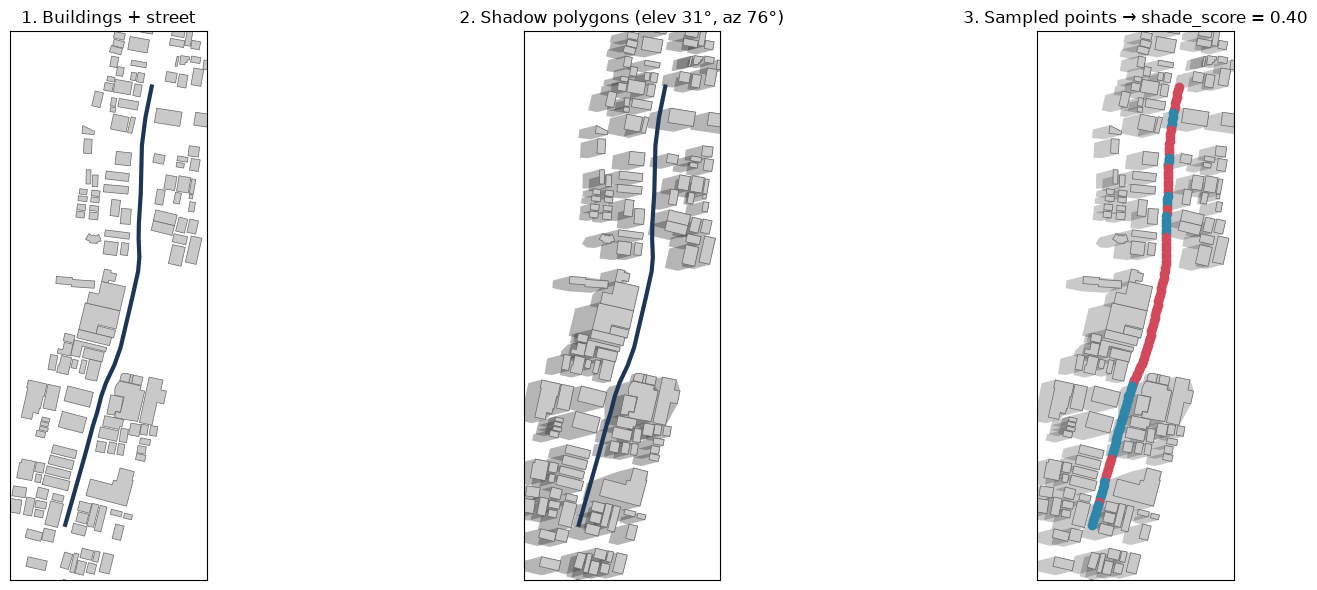

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

minx, miny, maxx, maxy = buf.bounds
for ax in axes:
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

# Panel 1 — footprints + street
nearby.plot(ax=axes[0], facecolor='#c9c9c9', edgecolor='#666', linewidth=0.5)
xs, ys = street.xy
axes[0].plot(xs, ys, color='#1d3557', linewidth=3)
axes[0].set_title('1. Buildings + street')

# Panel 2 — shadow polygons
shadow_layer.plot(ax=axes[1], facecolor='#2b2b2b', alpha=0.35, edgecolor='none')
nearby.plot(ax=axes[1], facecolor='#c9c9c9', edgecolor='#666', linewidth=0.5)
axes[1].plot(xs, ys, color='#1d3557', linewidth=3)
axes[1].set_title(f'2. Shadow polygons (elev {elev:.0f}°, az {az:.0f}°)')

# Panel 3 — sampled points coloured by shade
shadow_layer.plot(ax=axes[2], facecolor='#2b2b2b', alpha=0.25, edgecolor='none')
nearby.plot(ax=axes[2], facecolor='#c9c9c9', edgecolor='#666', linewidth=0.5)
for pt, shaded in zip(samples, in_shade):
    axes[2].plot(pt.x, pt.y, marker='o', markersize=6,
                 color='#2e86ab' if shaded else '#d1495b')
axes[2].set_title(f'3. Sampled points → shade_score = {shade_score:.2f}')

plt.tight_layout()
plt.savefig('../results/shade_algorithm_walkthrough.png', dpi=140, bbox_inches='tight')
plt.show()

## Sanity checks

- At **noon** the shadow polygons should collapse toward the buildings (short shadows)
- At **sunset** they should stretch far to the east
- At **night** `build_shadow_layer` returns an empty series → every edge scores 1.0 in `compute_edge_shade`

The next notebook (`05_final_demo.ipynb`) runs the full pipeline end-to-end and produces the hero maps.